# Retail Demand Forecasting
## Data Cleaning and Initial EDA

This notebook focuses on understanding and preparing the retail sales data
and performing an initial exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")
stores = pd.read_csv(DATA_PATH + "stores.csv")
transactions = pd.read_csv(DATA_PATH + "transactions.csv")
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv")
oil = pd.read_csv(DATA_PATH + "oil.csv")

In [3]:
datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

train: (3000888, 6)
test: (28512, 5)
stores: (54, 5)
transactions: (83488, 3)
holidays: (350, 6)
oil: (1218, 2)


In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


TRAIN


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



TEST


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0



STORES


...

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



HOLIDAYS


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



OIL


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.dtypes)


TRAIN


id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object


TEST


id              int64
date           object
store_nbr       int64
family         object
onpromotion     int64
dtype: object


STORES


...

date            object
store_nbr        int64
transactions     int64
dtype: object


HOLIDAYS


date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object


OIL


date           object
dcoilwtico    float64
dtype: object

In [6]:
date_columns = {
    "train": train,
    "test": test,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in date_columns.items():
    df["date"] = pd.to_datetime(df["date"])

In [7]:
train["date"].min(), train["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [8]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    display(missing)


TRAIN


Series([], dtype: int64)


TEST


Series([], dtype: int64)


STORES


...

Series([], dtype: int64)


HOLIDAYS


Series([], dtype: int64)


OIL


dcoilwtico    43
dtype: int64

In [9]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

train: 0 duplicates
test: 0 duplicates
stores: 0 duplicates
transactions: 0 duplicates
holidays: 0 duplicates
oil: 0 duplicates


In [10]:
print("Rows:", len(train))
print("Stores:", train["store_nbr"].nunique())
print("Product Families:", train["family"].nunique())
print("Start Date:", train["date"].min())
print("End Date:", train["date"].max())

Rows: 3000888
Stores: 54
Product Families: 33
Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [11]:
duplicate_keys = train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

print("Duplicate date-store-family combinations:", duplicate_keys)

Duplicate date-store-family combinations: 0


In [12]:
train["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [13]:
print("Zero sales:", (train["sales"] == 0).sum())
print(
    "Zero sales percentage:",
    round((train["sales"] == 0).mean() * 100, 2),
    "%"
)

Zero sales: 939130
Zero sales percentage: 31.3 %


In [14]:
print("Negative sales:", (train["sales"] < 0).sum())

Negative sales: 0


In [15]:
print(
    "Rows with promotion:",
    round((train["onpromotion"] > 0).mean() * 100, 2),
    "%"
)

Rows with promotion: 20.37 %


In [16]:
oil[oil["dcoilwtico"].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [17]:
oil_missing_dates = oil.loc[
    oil["dcoilwtico"].isna(), "date"
]

holidays[holidays["date"].isin(oil_missing_dates)][
    ["date", "type", "locale", "description"]
]

,date,type,locale,description
41,2013-01-01,Holiday,National,Primer dia del ano
89,2013-12-25,Holiday,National,Navidad
92,2014-01-01,Holiday,National,Primer dia del ano
99,2014-04-18,Holiday,National,Viernes Santo
120,2014-07-04,Event,National,Mundial de futbol Brasil: Cuartos de Final
155,2014-12-25,Holiday,National,Navidad
159,2015-01-01,Holiday,National,Primer dia del ano
162,2015-02-16,Holiday,National,Carnaval
166,2015-04-03,Holiday,National,Viernes Santo
179,2015-07-03,Holiday,Local,Cantonizacion de El Carmen


In [18]:
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

### Handling Missing Oil Prices

The oil dataset contains missing values in the `dcoilwtico` column, which represents the daily oil price.

During the inspection, we found 43 missing oil-price values. Several of the missing dates also appear in the holidays dataset, but not all missing dates were verified as holidays.

Since oil price is a time-dependent feature, we will not remove these rows. Instead, missing values will be imputed using forward fill, with backward fill used only when no previous value is available.

This approach preserves the dates and avoids removing observations that may be important for demand analysis.

In [19]:
oil["dcoilwtico"].isna().sum()

0

After imputation, we verify that no missing oil-price values remain.

### Duplicate Check

We check for duplicate rows across all datasets to ensure that duplicated observations do not affect the analysis or lead to incorrect aggregations during data integration.

In [20]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

train: 0 duplicate rows
test: 0 duplicate rows
stores: 0 duplicate rows
transactions: 0 duplicate rows
holidays: 0 duplicate rows
oil: 0 duplicate rows


### Train Data Granularity Check

The training data is expected to contain one observation for each combination of date, store, and product family. We therefore check whether any duplicate combinations exist.

In [21]:
train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

0

### Date Validation

Since this project focuses on time-series demand forecasting, we verify that the date columns are correctly formatted and inspect the date ranges across the datasets.

In [22]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(f"{name}: {df['date'].dtype}")

train: datetime64[ns]
test: datetime64[ns]
transactions: datetime64[ns]
holidays: datetime64[ns]
oil: datetime64[ns]


In [23]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(
            f"{name}: "
            f"{df['date'].min().date()} → "
            f"{df['date'].max().date()}"
        )

train: 2013-01-01 → 2017-08-15
test: 2017-08-16 → 2017-08-31
transactions: 2013-01-01 → 2017-08-15
holidays: 2012-03-02 → 2017-12-26
oil: 2013-01-01 → 2017-08-31


In [24]:
print(
    "Train unique dates:",
    train["date"].nunique()
)

print(
    "Train total rows:",
    len(train)
)

Train unique dates: 1684
Train total rows: 3000888


In [25]:
print(
    "Train date range:",
    train["date"].max() - train["date"].min()
)

Train date range: 1687 days 00:00:00


In [26]:
expected_dates = pd.date_range(
    start=train["date"].min(),
    end=train["date"].max(),
    freq="D"
)

actual_dates = train["date"].drop_duplicates().sort_values()

missing_dates = expected_dates.difference(actual_dates)

print("Expected dates:", len(expected_dates))
print("Actual dates:", len(actual_dates))
print("Missing dates:", len(missing_dates))

Expected dates: 1688
Actual dates: 1684
Missing dates: 4


In [27]:
print("Missing dates:")
for date in missing_dates:
    print(date.date())

Missing dates:
2013-12-25
2014-12-25
2015-12-25
2016-12-25


### Missing Calendar Dates

The training data contains four missing calendar dates:

- December 25, 2013
- December 25, 2014
- December 25, 2015
- December 25, 2016

All four missing dates correspond to December 25. These dates are not individual missing sales values; the entire dates are absent from the training dataset.

Therefore, we will not impute or add sales observations for these dates. Adding artificial sales values could introduce assumptions that are not supported by the data.

### Decision

The missing dates will be kept as absent dates during the initial analysis. 
The forecasting models will use the available observations without creating artificial demand values for these dates.

### Sales Validation

Sales is the target variable for the demand forecasting task. We inspect its distribution, range, zero values, and negative values to identify potential data quality issues before performing exploratory analysis.

In [28]:
print("Sales summary:")
display(train["sales"].describe())

Sales summary:


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [29]:
print("Zero sales:", (train["sales"] == 0).sum())
print("Zero sales percentage:", round((train["sales"] == 0).mean() * 100, 2), "%")
print("Negative sales:", (train["sales"] < 0).sum())

Zero sales: 939130
Zero sales percentage: 31.3 %
Negative sales: 0


### Sales Validation Result

The sales variable contains no negative values, indicating no obvious invalid negative demand records.

However, 31.3% of the observations have zero sales. These zero values are retained because they represent potentially meaningful demand patterns and will be considered during the analysis of regular and intermittent demand.

## Initial Exploratory Data Analysis

The initial EDA examines overall sales trends and patterns over time, followed by differences across product families, stores, months, weekdays, and promotion status.

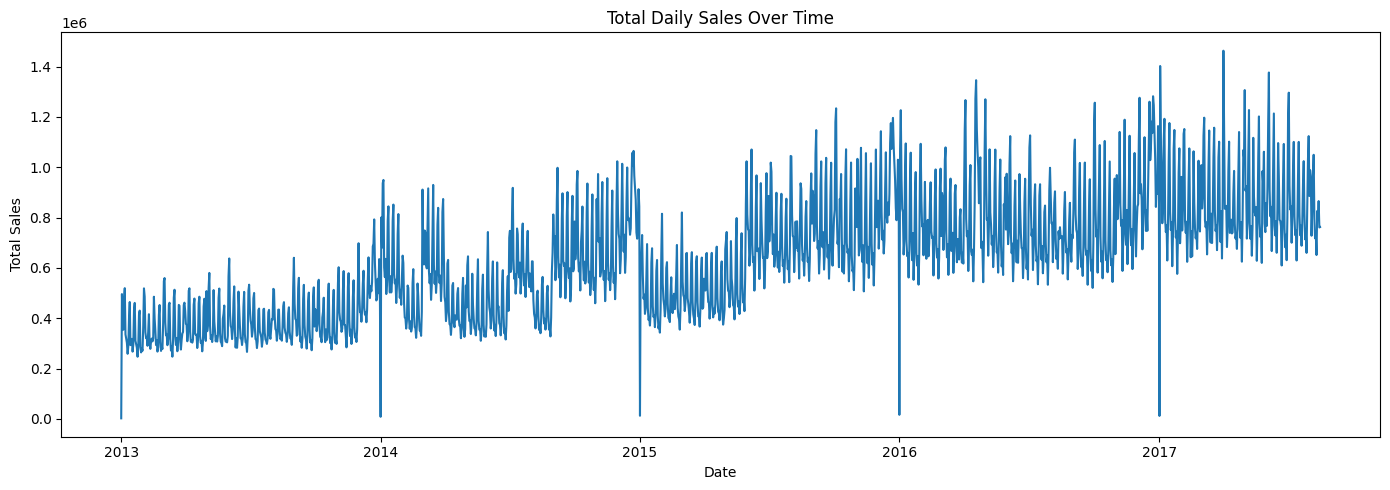

In [30]:
daily_sales = (
    train.groupby("date", as_index=False)["sales"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Insight

The overall daily sales show an increasing trend over the observed period, with sales levels generally higher in later years than in the earlier years.

The series also shows strong day-to-day variability and recurring patterns over time, suggesting the presence of temporal seasonality.

Several dates show very low or zero total sales, which is consistent with the high proportion of zero-sales observations identified during data validation. These observations are retained because they may represent meaningful demand patterns.

### 2. Overall Sales Trend with 7-Day Rolling Average

A 7-day rolling average is used to smooth daily fluctuations and provide a clearer view of the underlying sales trend.

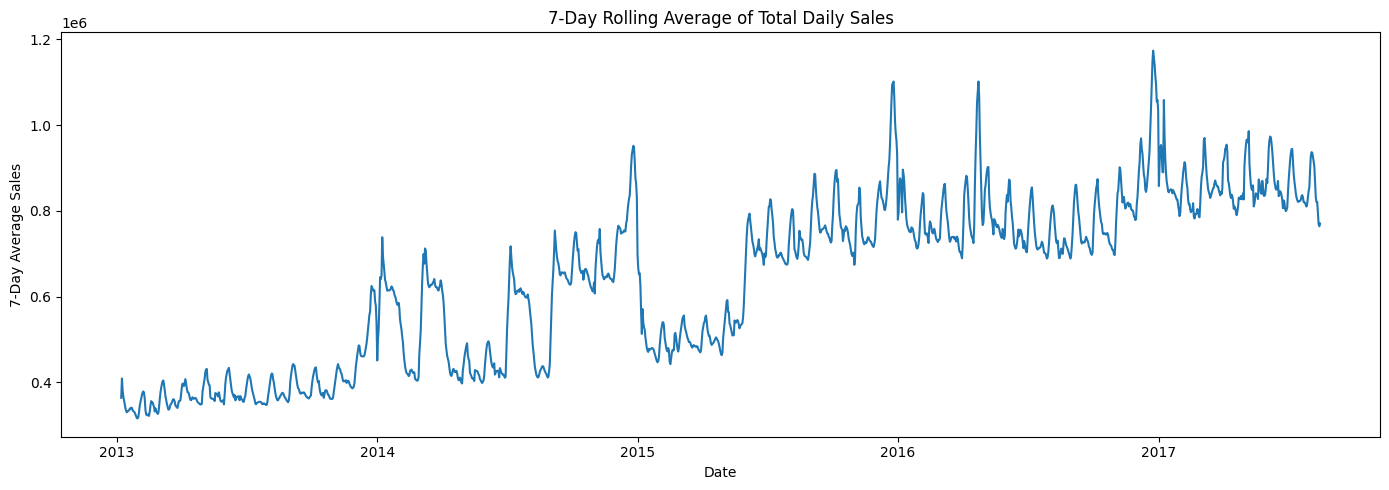

In [31]:
daily_sales["rolling_7d"] = (
    daily_sales["sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_7d"]
)

plt.title("7-Day Rolling Average of Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("7-Day Average Sales")

plt.tight_layout()
plt.show()

### Insight

The 7-day rolling average shows an overall upward trend in sales over the observed period.

Sales levels are generally higher in 2016 and 2017 compared with the earlier years. The series also contains recurring fluctuations, suggesting that temporal patterns and seasonality may influence demand.

A noticeable decline occurs during part of 2015, followed by a recovery and a higher sales level in the later period.

### 3. Top 10 Product Families by Total Sales

We aggregate total sales by product family to identify the product categories that contribute most to overall demand.

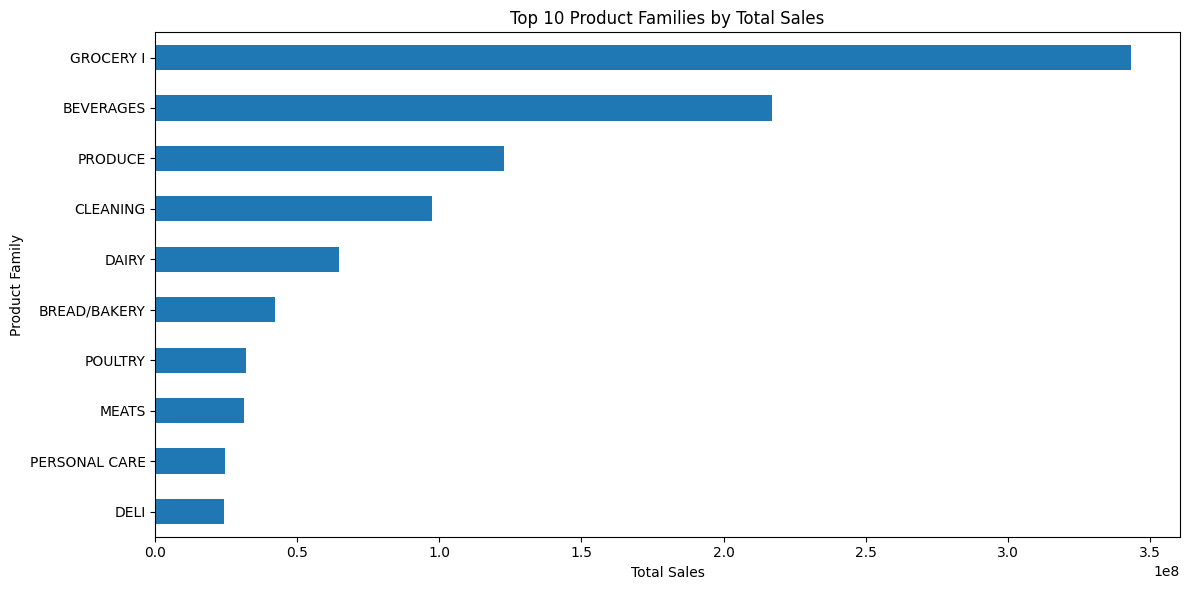

In [32]:
family_sales = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_families = family_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_families.sort_values().plot(kind="barh")

plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")

plt.tight_layout()
plt.show()

### Insight

GROCERY I has the highest total sales among all product families, followed by BEVERAGES and PRODUCE.

The difference between the top product family and the others is substantial, indicating that demand is not evenly distributed across product families.

This suggests that product family should be considered as an important feature when building the demand forecasting model.

### 4. Sales by Promotion Status

We compare total sales on days with and without promotions to examine whether promotional activity is associated with higher demand.

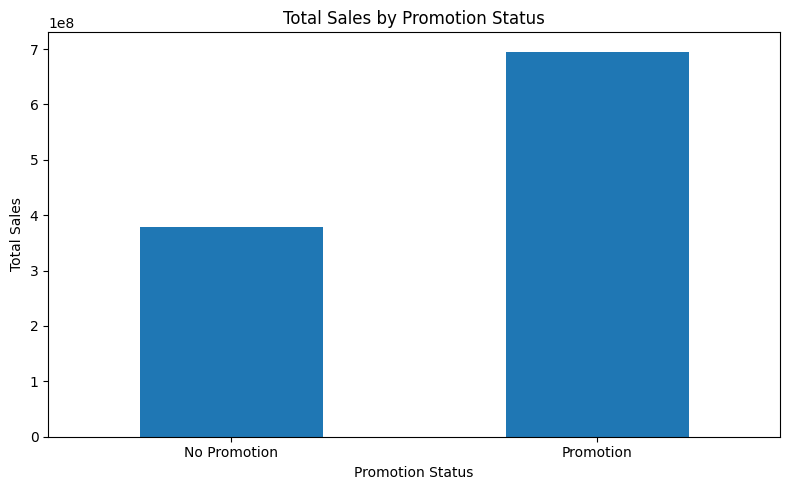

In [33]:
promotion_sales = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .sum()
)

promotion_sales.index = ["No Promotion", "Promotion"]

plt.figure(figsize=(8, 5))

promotion_sales.plot(kind="bar")

plt.title("Total Sales by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Promotion Sales Validation

Total sales are higher for observations with promotions. However, total sales alone may be affected by the different number of observations in each group.

Therefore, we compare the average sales per observation to better understand the relationship between promotion activity and demand.

In [34]:
promotion_summary = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .agg(["count", "mean", "median", "sum"])
)

promotion_summary.index = ["No Promotion", "Promotion"]

display(promotion_summary)

,count,mean,median,sum
No Promotion,2389559,158.246681,3.0,3.781398e+08
Promotion,611329,1137.693730,373.0,6.955052e+08


In [35]:
no_promo_mean = promotion_summary.loc["No Promotion", "mean"]
promo_mean = promotion_summary.loc["Promotion", "mean"]

percentage_difference = (
    (promo_mean - no_promo_mean) / no_promo_mean
) * 100

print(
    "Average sales difference:",
    round(percentage_difference, 2),
    "%"
)

Average sales difference: 618.94 %


### Insight

Observations with promotions have substantially higher average sales than observations without promotions.

The average sales are 1,137.69 for promoted observations compared with 158.25 for non-promoted observations, representing a difference of approximately 618.94%.

This strong association suggests that promotion activity may be an important predictive feature for demand forecasting. However, this analysis does not establish a causal relationship between promotions and sales.

### 5. Average Sales by Month

We examine the average sales across months to identify recurring monthly patterns and potential seasonal effects in demand.

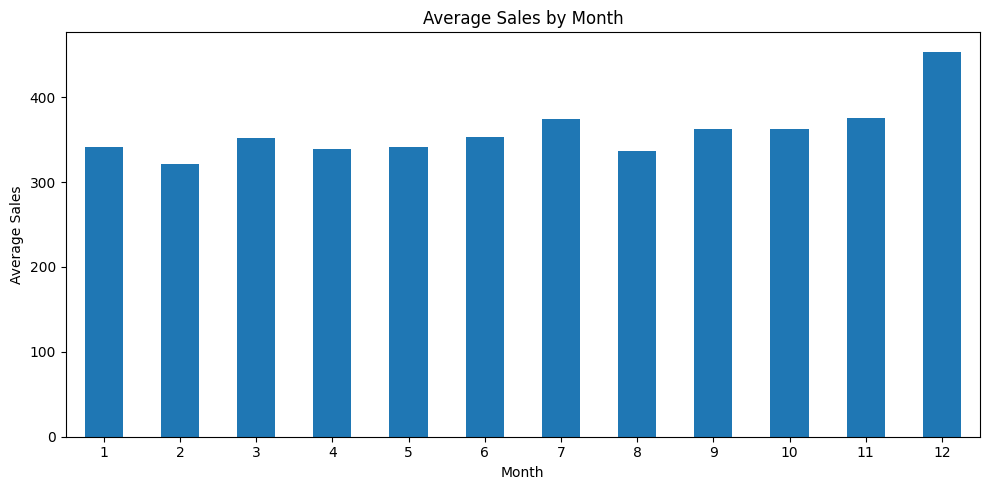

In [36]:
monthly_sales = (
    train.groupby(train["date"].dt.month)["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Average sales vary across months, indicating a recurring monthly pattern in demand.

December has the highest average sales, while February has the lowest. Although the differences between most months are moderate, the monthly variation suggests that month-related seasonal features may be useful for demand forecasting.

## Advanced EDA & Feature Exploration

The following sections extend the initial exploratory analysis with calendar-based patterns, store-level differences, and feature preparation for demand forecasting.

### 6. Sales by Day of Week

We examine average sales across days of the week to identify whether demand follows a recurring weekly pattern.

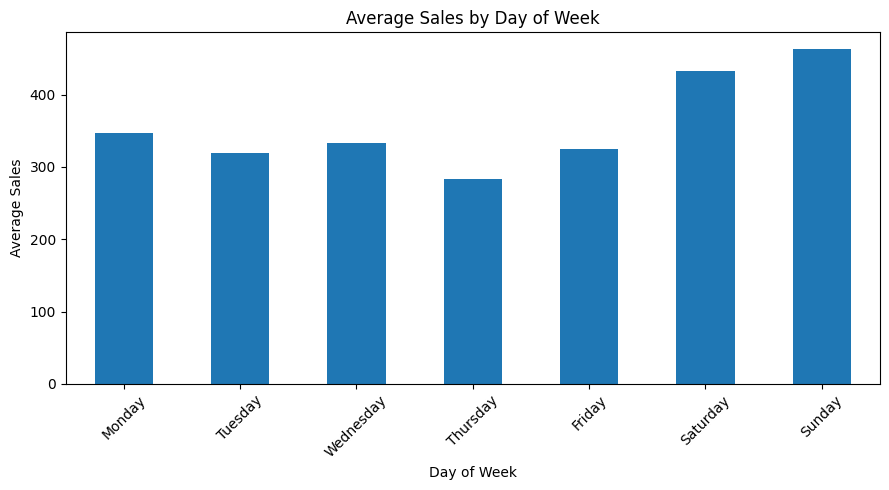

weekday
Monday       346.54
Tuesday      319.82
Wednesday    332.91
Thursday     283.54
Friday       325.24
Saturday     433.34
Sunday       463.09
Name: sales, dtype: float64


In [37]:
train['weekday'] = train['date'].dt.day_name()

weekday_sales = train.groupby('weekday')['sales'].mean()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                  'Friday', 'Saturday', 'Sunday']
weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(9, 5))
weekday_sales.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_sales.round(2))

### Insight

Sales are highest on weekends, with Sunday (463.09) and Saturday (433.34) showing the strongest average demand. Thursday records the lowest average sales (283.54), while the remaining weekdays (Monday through Friday) show relatively similar levels, ranging from 283.54 to 346.54.

This weekly pattern, with weekend sales roughly 1.6 times higher than the weakest weekday, suggests that day-of-week should be included as a categorical feature in the forecasting model to capture this recurring demand cycle.

### 7. Sales by Year (Seasonality)

We examine sales trends across years to identify year-over-year growth.

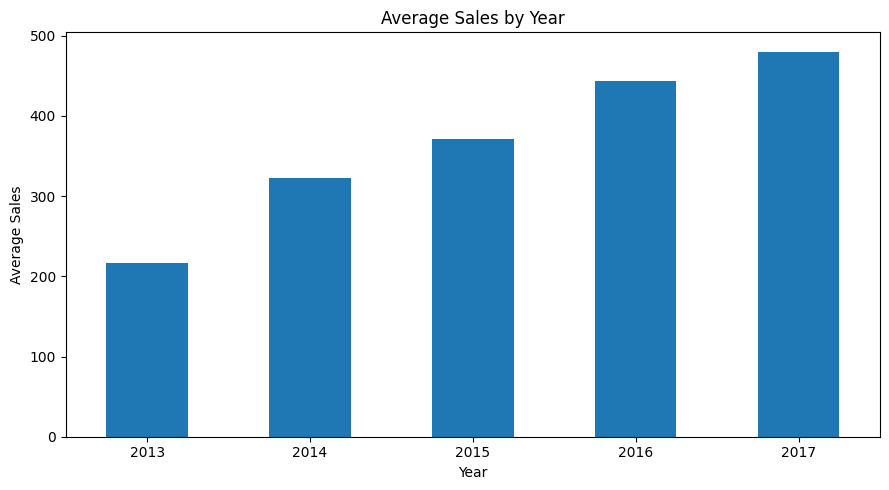

year
2013    216.48
2014    322.94
2015    371.36
2016    443.79
2017    480.12
Name: sales, dtype: float64


In [43]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month

yearly_sales = train.groupby('year')['sales'].mean()

plt.figure(figsize=(9, 5))
yearly_sales.plot(kind='bar')
plt.title('Average Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(yearly_sales.round(2))

### Verifying the Growth Trend

To verify whether the year-over-year growth reflects genuine demand increase or incomplete data tracking, we examine the PRODUCE family in isolation, since fresh categories are more likely to have been added to the system gradually.

In [42]:
produce_by_year = train[train['family'] == 'PRODUCE'].groupby('year')['sales'].mean()
print(produce_by_year.round(2))

year
2013       3.70
2014    1196.20
2015    1302.19
2016    2244.96
2017    2388.27
Name: sales, dtype: float64


### Insight

Average sales show a clear upward trend from 2013 (216.48) to 2017 (480.12). However, this growth is partly an artifact of incomplete tracking in early years: the PRODUCE family, for example, shows average sales of only 3.70 in 2013 compared with 1,196.20 in 2014 — a 323-fold increase that reflects the category not being fully recorded early in the dataset, rather than genuine demand growth.

This confirms that year should be included as a feature with caution, and that per-family tracking start dates should be verified (similar to the store cold-start check) before treating year-over-year growth as a reliable trend signal.

### 8. Sales by Store

We examine sales distribution across individual stores to identify high- and low-performing locations.

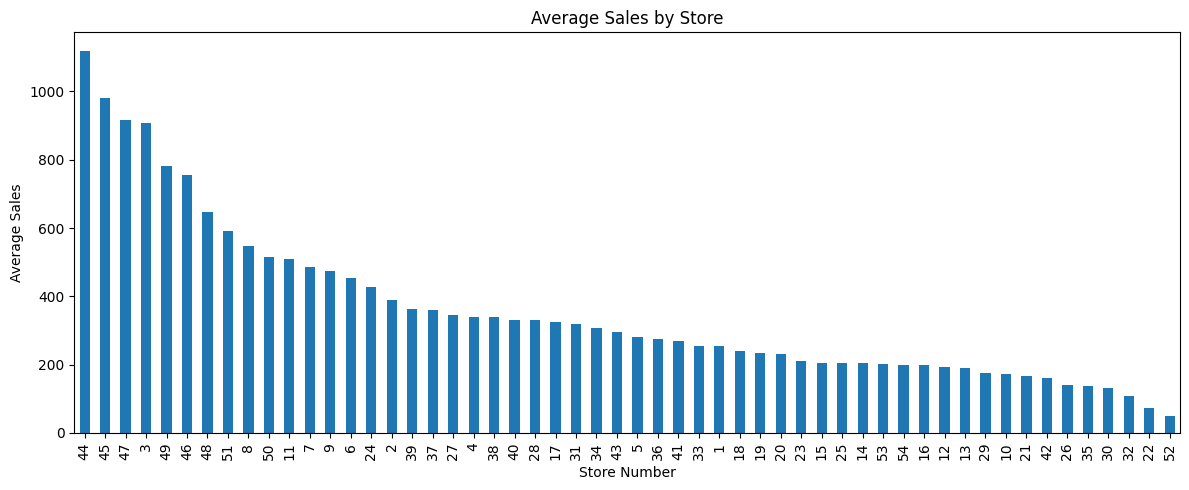

store_nbr
44    1117.245254
45     980.673908
47     916.798209
3      908.405495
49     781.330450
Name: sales, dtype: float64
...
store_nbr
35    138.139340
30    132.838006
32    107.100626
22     73.601845
52     48.516694
Name: sales, dtype: float64


In [44]:
store_sales = train.groupby('store_nbr')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
store_sales.plot(kind='bar')
plt.title('Average Sales by Store')
plt.xlabel('Store Number')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

print(store_sales.head(5))
print("...")
print(store_sales.tail(5))

### Verifying Store Coverage

Before interpreting store-level averages, we verify whether all stores have equal data coverage across the period.

In [47]:
store_days = train.groupby('store_nbr')['date'].nunique()

print("Days recorded per store — Store 52:", store_days.loc[52])
print("Average days across all stores:", store_days.mean().round(0))

Days recorded per store — Store 52: 1684
Average days across all stores: 1684.0


### Insight

Average sales vary substantially across stores, from 1,117.25 (Store 44) to 48.52 (Store 52) — roughly a 23-fold difference. All stores have identical data coverage (1,684 recorded days), so the gap is not caused by missing records.

However, Store 52 opened partway through the data period, meaning its average includes an extended stretch of zero sales prior to opening rather than reflecting weak performance once operational. Store-level averages should therefore be interpreted alongside each store's operational start date, and a store-opening feature (or excluding pre-opening records) would improve the reliability of store comparisons.

### 9. Sales by Store Type

We examine whether store type, as defined in the stores metadata, is associated with different demand levels.

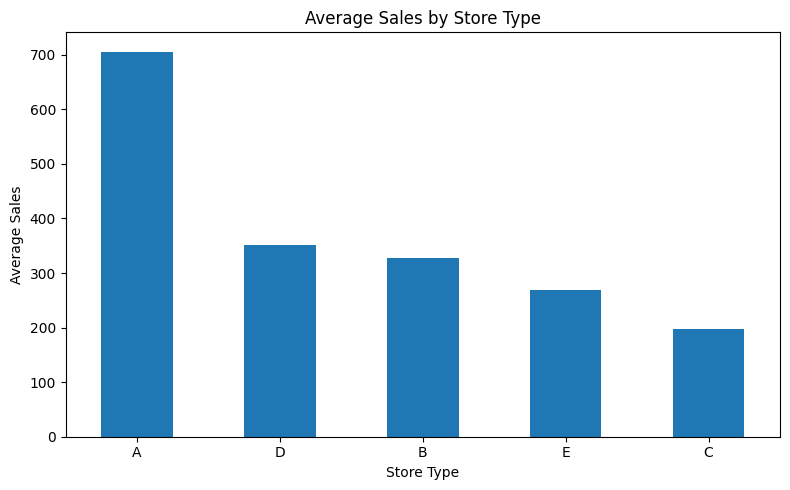

type
A    705.88
D    350.98
B    326.74
E    269.12
C    197.26
Name: sales, dtype: float64


In [48]:
stores = pd.read_csv(DATA_PATH + "stores.csv")
train_stores = train.merge(stores, on='store_nbr', how='left')

type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
type_sales.plot(kind='bar')
plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(type_sales.round(2))

### Insight

Store type is strongly associated with sales volume. Type A stores average 705.88 in sales, more than double the next highest type (D at 350.98), while Type C records the lowest average at 197.26 — a 3.6-fold gap between the highest and lowest types.

Notably, the ordering does not follow the alphabetical labels (D outperforms B, and E outperforms C), indicating that store type reflects an operational classification rather than a simple size ranking. This makes store type a useful categorical feature for the forecasting model, as it captures systematic differences in demand levels that are not evident from the store number alone.

### 10. Promotion Effect by Product Family

The initial analysis showed that promoted observations have substantially higher average sales overall. We now examine whether this effect is consistent across product families or concentrated in specific categories.

In [49]:
promo_effect = train.groupby(['family', train['onpromotion'] > 0])['sales'].mean().unstack()
promo_effect.columns = ['No Promotion', 'Promotion']

promo_effect['lift_pct'] = (
    (promo_effect['Promotion'] - promo_effect['No Promotion']) 
    / promo_effect['No Promotion'] * 100
).round(1)

promo_effect = promo_effect.sort_values('lift_pct', ascending=False)

print(promo_effect.head(10))
print("...")
print(promo_effect.tail(10))

                            No Promotion    Promotion  lift_pct
family                                                         
SCHOOL AND OFFICE SUPPLIES      1.022018    44.529107    4257.0
BABY CARE                       0.109624     1.660377    1414.6
PET SUPPLIES                    3.507379    15.835244     351.5
HOME AND KITCHEN II            10.275239    41.158133     300.6
PRODUCE                       792.101911  2438.220197     207.8
HOME APPLIANCES                 0.456876     1.396552     205.7
LAWN AND GARDEN                 5.510703    16.786862     204.6
HOME CARE                     101.956009   309.444864     203.5
PLAYERS AND ELECTRONICS         6.081521    17.363958     185.5
BEAUTY                          3.078452     8.291266     169.3
...
                No Promotion    Promotion  lift_pct
family                                             
MEATS             303.081088   467.301631      54.2
PERSONAL CARE     220.878968   338.746698      53.4
BREAD/BAKERY      37

### Insight

The promotional effect varies dramatically across product families, ranging from a 4,257% lift (School and Office Supplies) to 23.9% (Prepared Foods) — a spread that the aggregate figure of 618.94% conceals entirely.

However, the largest percentage lifts occur in categories with very low baseline sales: School and Office Supplies averages 1.02 units without promotion versus 44.53 with, and Baby Care averages 0.11 versus 1.66. In absolute terms, the most commercially significant lift is in Produce, which rises from 792.10 to 2,438.22 — a 207.8% increase on an already substantial base.

Books shows no promotional data at all, indicating the category was never promoted across the entire period.

This suggests that promotion should be modelled as an interaction with product family rather than as a single global effect, since the response magnitude differs by two orders of magnitude between categories.

### 11. Holiday Effect on Sales

We examine whether sales differ on public holidays compared with regular days. The holidays dataset distinguishes several event types, including transferred holidays that are officially moved to another date.

In [50]:
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

national_holidays = holidays[
    (holidays["locale"] == "National") & (holidays["transferred"] == False)
]["date"].unique()

daily_sales = train.groupby("date")["sales"].mean()

holiday_sales = daily_sales[daily_sales.index.isin(national_holidays)]
regular_sales = daily_sales[~daily_sales.index.isin(national_holidays)]

print("Holidays:", len(holiday_sales), "days | Mean sales:", round(holiday_sales.mean(), 2))
print("Regular:", len(regular_sales), "days | Mean sales:", round(regular_sales.mean(), 2))
print("Difference:", round((holiday_sales.mean() - regular_sales.mean()) / regular_sales.mean() * 100, 2), "%")

Holidays: 136 days | Mean sales: 419.34
Regular: 1548 days | Mean sales: 352.37
Difference: 19.01 %


In [51]:
np.random.seed(42)

random_diffs = []
for _ in range(10):
    random_days = np.random.choice(regular_sales.index, size=136, replace=False)
    random_mean = daily_sales[daily_sales.index.isin(random_days)].mean()
    others_mean = daily_sales[~daily_sales.index.isin(random_days)].mean()
    random_diffs.append((random_mean - others_mean) / others_mean * 100)

print("Holiday effect:", round((holiday_sales.mean() - regular_sales.mean()) / regular_sales.mean() * 100, 2), "%")
print("Random samples (10 runs):", [round(d, 2) for d in random_diffs])
print("Max random difference:", round(max(abs(d) for d in random_diffs), 2), "%")

Holiday effect: 19.01 %
Random samples (10 runs): [-2.04, -6.02, 2.15, -2.54, -0.87, 2.23, -4.02, 3.44, 1.65, -5.41]
Max random difference: 6.02 %


### Insight

Sales on national holidays average 419.34 compared with 352.37 on regular days, a 19.01% increase across 136 holiday observations.

To confirm this is not an artifact of random variation, we compared the holiday effect against ten random samples of equal size (136 days) drawn from regular days. The random differences ranged from -6.02% to +3.44%, with a maximum absolute deviation of 6.02% — roughly one third of the observed holiday effect, and centred around zero as expected for noise.

This confirms that national holidays represent a genuine demand signal rather than random fluctuation, and should be included as a binary feature in the forecasting model. Transferred holidays were excluded from this analysis, as the dataset documentation indicates they behave as ordinary working days.

### 12. Merging Supplementary Data

We merge store metadata, daily transactions, and oil prices into the main dataset to prepare a unified table for feature exploration and modelling.

In [52]:
transactions = pd.read_csv(DATA_PATH + "transactions.csv")
transactions["date"] = pd.to_datetime(transactions["date"])

oil = pd.read_csv(DATA_PATH + "oil.csv")
oil["date"] = pd.to_datetime(oil["date"])
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

df = train.merge(stores, on="store_nbr", how="left")
df = df.merge(transactions, on=["date", "store_nbr"], how="left")
df = df.merge(oil, on="date", how="left")

df["dcoilwtico"] = df["dcoilwtico"].ffill().bfill()

print("Shape after merging:", df.shape)
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Shape after merging: (3000888, 15)

Missing values:
transactions    245784
dtype: int64


In [53]:
missing_trans = df[df["transactions"].isna()]

print("Sales on rows with missing transactions:")
print(missing_trans["sales"].describe().round(2))
print("\nZero-sales percentage:", round((missing_trans["sales"] == 0).mean() * 100, 2), "%")


Sales on rows with missing transactions:
count    245784.00
mean          9.69
std         234.50
min           0.00
25%           0.00
50%           0.00
75%           0.00
max       19988.63
Name: sales, dtype: float64

Zero-sales percentage: 98.68 %


### Handling Missing Transactions

The transactions dataset does not record entries for days when a store had no activity. We verify this by examining sales on rows with missing transaction counts.

In [54]:
missing_trans = df[df["transactions"].isna()]

print("Zero-sales percentage on missing-transaction rows:",
      round((missing_trans["sales"] == 0).mean() * 100, 2), "%")

df["transactions"] = df["transactions"].fillna(0)

print("\nMissing values after filling:")
print(df.isna().sum().sum())

Zero-sales percentage on missing-transaction rows: 98.68 %

Missing values after filling:
0


### Insight

Transaction counts are missing for 245,784 rows (8.2% of the dataset). Sales on these rows are zero in 98.68% of cases, confirming that missing entries correspond to days when a store recorded no activity rather than to data collection errors.

We therefore fill these values with zero rather than imputing a mean or median, since imputing an average transaction count would introduce artificial activity on days when stores were closed or not yet operational.

### 13. Correlation Between Numerical Features

We examine the linear relationships between numerical variables to identify which features carry predictive signal for sales, and to detect any redundancy between them.

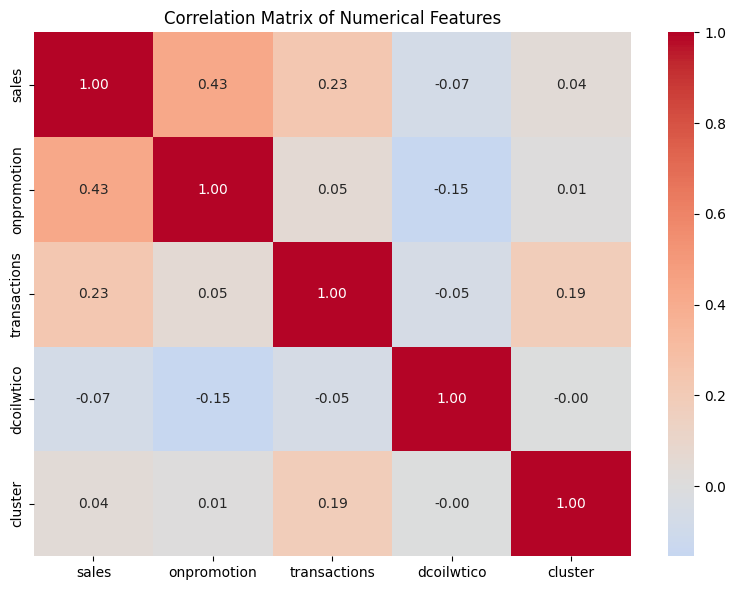

sales           1.000
onpromotion     0.428
transactions    0.233
cluster         0.039
dcoilwtico     -0.075
Name: sales, dtype: float64


In [55]:
numeric_cols = ["sales", "onpromotion", "transactions", "dcoilwtico", "cluster"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

print(corr["sales"].sort_values(ascending=False).round(3))

### Insight

Promotion status shows the strongest linear relationship with sales (r = 0.428), consistent with the family-level analysis where promotional lift ranged from 24% to over 4,000% depending on category. Transaction count follows at r = 0.233, reflecting general store activity but not the monetary value of individual purchases.

Store cluster (r = 0.039) and oil price (r = -0.075) show negligible linear correlation with sales. The cluster result is expected, since cluster is a categorical identifier rather than an ordered quantity, and linear correlation is not a meaningful measure for it.

The weak oil-price correlation is notable given that the dataset documentation highlights Ecuador's oil dependence. This suggests that any macroeconomic effect operates over longer horizons than daily sales variation, and that oil price is unlikely to be a useful direct feature at the daily store-family level.

### 14. Candidate Features for Forecasting

Based on the patterns identified above, we summarise the features most likely to carry predictive signal, along with the reasoning behind each.

**Strong candidates**

- `onpromotion` — the strongest single predictor (r = 0.428), with effects varying substantially by product family. Should be modelled as an interaction with family rather than a global effect.
- `family` — demand levels and promotional response differ by two orders of magnitude across categories.
- `day_of_week` — weekend sales are roughly 1.6 times higher than the weakest weekday.
- `is_holiday` — national holidays show a 19% uplift, confirmed against random-sample variation.
- `store_type` — a 3.6-fold gap between the highest and lowest performing types.
- `store_nbr` — substantial store-level variation beyond what type alone explains.

**Moderate candidates**

- `transactions` — captures general store activity (r = 0.233), though it reflects footfall rather than basket value.
- `month` — moderate seasonal variation, with December highest and February lowest.

**Weak or excluded**

- `dcoilwtico` — negligible correlation at the daily level (r = -0.075). Any macroeconomic effect appears to operate over longer horizons than daily demand variation.
- `year` — shows a strong upward trend, but this is partly an artifact of incomplete category tracking in early periods and should not be used as a direct trend feature without correction.
- `cluster` — a categorical identifier; linear correlation is not meaningful, though it may still hold value if encoded appropriately.

**Features to engineer**

Lag features (`lag_1`, `lag_7`, `lag_14`) and rolling statistics (`rolling_mean_7`, `rolling_mean_14`) are expected to be essential for time-series forecasting, capturing recent demand levels and short-term momentum that none of the raw columns provide.

### 15. Forecasting Granularity

Based on the structure of the data and the patterns identified above, we define the forecasting granularity as **date × store × product family** — the same level at which the raw data is recorded.

This level is chosen because store-level and family-level effects are both substantial and independent: average sales vary 23-fold across stores and show a 3.6-fold gap across store types, while promotional response ranges from 24% to over 4,000% depending on product family. Aggregating to either store level or family level alone would discard signal that the other dimension carries.

This yields 1,782 individual time series (54 stores × 33 families), each forecast over a 15-day horizon.

### 16. Saving the Modeling Dataset

We save the merged and cleaned dataset for use in the feature engineering and modelling stages.

In [56]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/modeling_dataset.csv", index=False)

print("Saved:", df.shape)
print("Columns:", list(df.columns))

Saved: (3000888, 15)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'weekday', 'year', 'month', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico']
